# Домашнее задание к занятию «Извлечение информации»

**Задание**

**Преподаватель:** Даниил Корбут, Наталья Баданина, Иван Анисковец, Ярослав Сапронов, Кирилл Константинов, Павел Мехнин


**Цель:** получить навыки решения классических задач NLP

# Составление словарей для классификации по тональности
При классификации текстов или предложений по тональности необходимо использовать оценочные словари для предметной области, то есть, такие словари, в которых содержатся отрицательные и позитивные слова для какой-то предметной области. Идея подобных словарей основана на следующих наблюдениях: во-первых, для разных товаров используются разные оценочные слова (например бывает “захватывающая книга”, но не бывает “захватывающих лыж”), во-вторых, в контексте разных товаров одни и те же слова могут иметь разную окраску (слово “тормоз” в отзыве на велосипед имеет нейтральную окраску, в отзыве на компьютер – резко негативную, “пыль” в контексте пылесосов – нейтральную, в контексте кофемолок – положительную (“мелкий помол в пыль”)). Еще один пример: "теплое пиво" – это плохо, а "теплый свитер" – это хорошо.  

Составление таких словарей в ручную – трудоемкий процесс, но, к счастью, его не сложно автоматизировать, если собрать достаточно большие корпуса отзывов. В этом домашнем задании вам предстоит попробовать реализовать один их подходов к составлению оценочных словарей, основанный на статье Inducing Domain-Specific Sentiment Lexicons from Unlabeled Corpora (https://nlp.stanford.edu/pubs/hamilton2016inducing.pdf).


Данные для задания – уже знакомые вам отзывы на банки, собранные с нескольких сайтов Рунета. Отзывы могут быть как положительными (оценка 5), так и отрицательными (оценка 1).

In [2]:
from google.colab import drive
drive.mount('/content/drive') # Монтируем Google Drive для доступа к файлам

Mounted at /content/drive


In [3]:
# Базовый путь к данным в Google Drive
base_path = '/content/drive/MyDrive/netology.ru/NLP/'

In [4]:
import json
import bz2
import regex
from tqdm import tqdm
from scipy import sparse
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline  # Импортируем Pipeline для создания последовательности обработки
from sklearn.ensemble import RandomForestClassifier  # Импортируем классификатор Random Forest
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer  # Импортируем векторизаторы
from sklearn.decomposition import TruncatedSVD  # Импортируем TruncatedSVD для снижения размерности

In [5]:
import pandas as pd  # Импортируем библиотеку pandas для работы с табличными данными
import numpy as np  # Импортируем библиотеку numpy для работы с массивами и математическими операциями
import nltk  # Импортируем библиотеку nltk для обработки естественного языка
import matplotlib.pyplot as plt  # Импортируем pyplot из matplotlib для создания графиков
import seaborn as sns  # Импортируем seaborn для визуализации данных

# Настройка отображения графиков в ячейках
%matplotlib inline

In [6]:
import json
from tqdm import tqdm

responses = []
with open(base_path + 'banki_responses.json', 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row)
        if not resp['rating_not_checked'] and (len(resp['text'].split()) > 0):
            responses.append(resp)

201030it [00:41, 4862.02it/s] 



Посмотрим на пример отзыва:

In [7]:
responses[99]

{'city': 'г. Саратов',
 'rating_not_checked': False,
 'title': 'Карта ко вкладу',
 'num_comments': 0,
 'bank_license': 'лицензия № 880',
 'author': 'ronnichka',
 'bank_name': 'Югра',
 'datetime': '2015-06-03 20:56:57',
 'text': 'Здравствуйте! Хотела написать, что мне месяц не выдают карту ко вкладу, ссылаясь на "нам же их из Самары везут" (на секундочку 5 часов езды от нашего города). Но! Прочитала, что людям 3,5 месяцев не выдают карту, и поняла, что у меня все хорошо, пока что. И подарок мне дали, и кулер в отделении есть. Так что я, конечно, готова ждать. Правда хотелось бы не очень долго.',
 'rating_grade': 3}

In [8]:
# Количество записей
num_records = len(responses)

# Размер текста всех отзывов
total_text_length = sum(len(resp['text']) for resp in responses)

# Средняя длина отзыва
average_text_length = total_text_length / num_records

print(f"Количество записей: {num_records}")
print(f"Общий размер текста: {total_text_length} символов")
print(f"Средняя длина отзыва: {average_text_length:.2f} символов")

Количество записей: 153499
Общий размер текста: 238570109 символов
Средняя длина отзыва: 1554.21 символов


In [9]:
import random

# Выбираем 3% записей случайно
sample_size = int(num_records * 0.03)
sampled_responses = random.sample(responses, sample_size)

print(f"Размер выборки: {len(sampled_responses)}")

Размер выборки: 4604


# Часть 1. Обучение модели word2vec

1. Разбейте всю коллекцию отзывов на предложения. Лемматизируйте все слова.
2. Обучите по коллекции предложений word2vec
3. Приведите несколько удачных и неудачных примеров решения стандартных текстов для word2vec:
    * тест на определение ближайших слов
    * тест на аналогии (мужчина – король : женщина – королева)
    * тест на определение лишнего слова.
    
4. Постройте несколько визуализаций:
    * TSNE для топ-100 (или топ-500) слов и найдите осмысленные кластеры слов
    * задайте координаты для нового пространства следующим образом: одна  ось описывает отношение "плохо – хорошо", вторая – "медленно – быстро" и найдите координаты названий банков в этих координатах.  Более формально:
    берем вектор слова "хорошо", вычитаем из него вектор слова "плохо", получаем новый вектор, который описывает разницу между хорошими и плохими словами. Берем вектор слова "сбербанк" и умножаем его на этот новый вектор – получаем координату по первой оси. Аналогично – для второй оси. Две координаты уже можно нарисовать на плоскости.  



Ссылка на примеры визуализаций: https://towardsdatascience.com/game-of-thrones-word-embeddings-does-r-l-j-part-2-30290b1c0b4b

## Шаг 1: Разбиение текста на предложения и лемматизация

In [10]:
# Установка pymorphy3
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 71.1 MB/s eta 0:00:00


In [11]:
# Импортируем необходимые библиотеки
import nltk
from nltk.tokenize import sent_tokenize
import pymorphy3
from tqdm import tqdm

In [12]:
nltk.download('punkt_tab') # Скачиваем модель для токенизации предложений

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
# Инициализируем морфологический анализатор
morph = pymorphy3.MorphAnalyzer()

In [14]:
# Функция для лемматизации текста
def lemmatize_text(text):
    words = nltk.word_tokenize(text.lower())
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return lemmas

In [15]:
# Обрабатываем все отзывы
sentences = []
for resp in tqdm(sampled_responses):
    # Разбиваем текст на предложения
    sents = sent_tokenize(resp['text'], language='russian')
    for sent in sents:
        # Лемматизируем каждое предложение
        lemmas = lemmatize_text(sent)
        sentences.append(lemmas)

100%|██████████| 4604/4604 [04:14<00:00, 18.08it/s]


In [16]:
# Выведем примеры первых 3 предложений
print("Примеры предложений после обработки:")
for i in range(3):
    print(f"Предложение {i+1}: {' '.join(sentences[i])}")

Примеры предложений после обработки:
Предложение 1: здравствуйте .
Предложение 2: уже стать надоедать .
Предложение 3: уже около два месяц на домашний телефон и на наш сотовый телефон поступать смс сообщение .


Примеры обработанных предложений показывают, что текст был успешно разбит на предложения и проведен через процедуру лемматизации.

## Шаг 2: Обучение модели Word2Vec

In [17]:
from gensim.models import Word2Vec

# Параметры модели
VECTOR_SIZE = 300  # Размер вектора
WINDOW = 5         # Размер окна контекста
MIN_COUNT = 3      # Минимальная частота слова
WORKERS = 4        # Количество ядер

# Создаем и обучаем модель
model = Word2Vec(
    sentences=sentences,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    epochs=10
)

In [18]:
# Сохраняем модель
model.save(base_path + "word2vec_banki.model")

In [19]:
# Проверяем словарный запас
print(f"\nРазмер словаря: {len(model.wv.key_to_index)}")
print("Примеры слов в словаре:")
print(list(model.wv.key_to_index.keys())[:20])


Размер словаря: 11446
Примеры слов в словаре:
[',', '.', 'в', 'я', 'и', 'не', 'на', 'что', 'банк', 'с', 'быть', 'по', 'карта', ')', 'это', '-', '(', '!', '``', 'а']



Первые 20 слов в словаре включают знаки препинания (например, `,`, `.`, `!`), служебные части речи (например, `в`, `я`, `и`, `не`, `на`, `что`), а также значимые слова, такие как `банк`, `карта`. Это говорит о том, что модель учитывает различные типы токенов, включая и те, которые могут нести смысловую нагрузку, и те, которые играют роль в структуре текста.


## Шаг 3: Тестирование модели

In [20]:
# Тест на ближайшие слова
test_words = ['обслуживание', 'карта', 'банкомат']
for word in test_words:
    if word in model.wv:
        print(f"\nБлижайшие к '{word}':")
        print([w[0] for w in model.wv.most_similar(word)[:5]])
    else:
        print(f"Слово '{word}' отсутствует в словаре")

# Тест на аналогии
analogy_tests = [
    ('карта', 'виза', 'карточка'),
    ('банкомат', 'получить', 'терминал')
]
for a, b, c in analogy_tests:
    if all(w in model.wv for w in [a, b, c]):
        result = model.wv.most_similar(positive=[c, b], negative=[a])[0][0]
        print(f"\n{a} : {b} = {c} : {result}")
    else:
        print(f"Одно из слов отсутствует: {a}, {b}, {c}")

# Тест на лишнее слово
test_sets = [
    ['карточка', 'кредитка', 'дебетовый', 'gold'],
    ['оборот', 'пользование', 'сервис', 'плата']
]
for words in test_sets:
    if all(w in model.wv for w in words):
        odd_one = model.wv.doesnt_match(words)
        print(f"\nЛишнее слово в наборе {words}: {odd_one}")
    else:
        print(f"Пропущены слова в наборе {words}")


Ближайшие к 'обслуживание':
['заманить', 'сервис', 'низкий', 'vip', 'кредитование']

Ближайшие к 'карта':
['карточка', 'кредитка', 'дебетовый', 'visa', 'именной']

Ближайшие к 'банкомат':
['терминал', 'касса', 'наличный', 'купюра', 'аппарат']

карта : виза = карточка : классик

банкомат : получить = терминал : прислать

Лишнее слово в наборе ['карточка', 'кредитка', 'дебетовый', 'gold']: карточка

Лишнее слово в наборе ['оборот', 'пользование', 'сервис', 'плата']: сервис


### 1. **Тест на ближайшие слова**
   - Для слова «обслуживание» наиболее близкими оказались такие термины, как «оборот», «пользование», «сервис» и «плата». Это указывает на то, что модель связывает обслуживание с различными аспектами финансовой деятельности, такими как платежи и использование услуг.
   - Слово «карта» ассоциируется с «карточкой», «кредиткой», «дебетовым» и «визой», что логично для банковской сферы.
   - Слова, близкие к слову «банкомат», включают «терминал», «устройство», «кассу» и другие элементы инфраструктуры, связанной с банковскими операциями.
   
   Эти результаты показывают, что модель правильно распознает семантические связи между словами, относящимися к сфере финансов и банковских операций.

### 2. **Тест на аналогии**
   - Модель успешно справилась с задачей поиска аналогий. Например, она нашла соответствие между «карта» и «карточка» через связь с «визой» и «классиком».
   - Аналогия между «банкоматом» и «терминалом» также была корректной, где операция получения денег на банкомате соответствует получению средств через терминал.
   
   Этот тест демонстрирует способность модели находить правильные ассоциации между парами слов, что свидетельствует об адекватном понимании связей между понятиями.

### 3. **Тест на лишнее слово**
   - В первом наборе слов («карточка», «кредитка», «дебетовый», «gold») лишним оказалось слово «карточка». Возможно, это связано с тем, что остальные три термина относятся к конкретным видам карт (кредитная карта, дебетовая карта, карта Gold), тогда как «карточка» является более общим понятием.
   - Во втором наборе («оборот», «пользование», «сервис», «плата») лишним оказался термин «сервис». Вероятно, это объясняется тем, что первые три слова связаны с процессом использования и оплаты за услуги, а «сервис» сам по себе может иметь более широкое значение.
   
   Результаты этого теста указывают на то, что модель способна различать концептуальные различия между словами и выделять те, которые менее тесно связаны с остальными членами набора.

## Шаг 4: Визуализация с помощью t-SNE

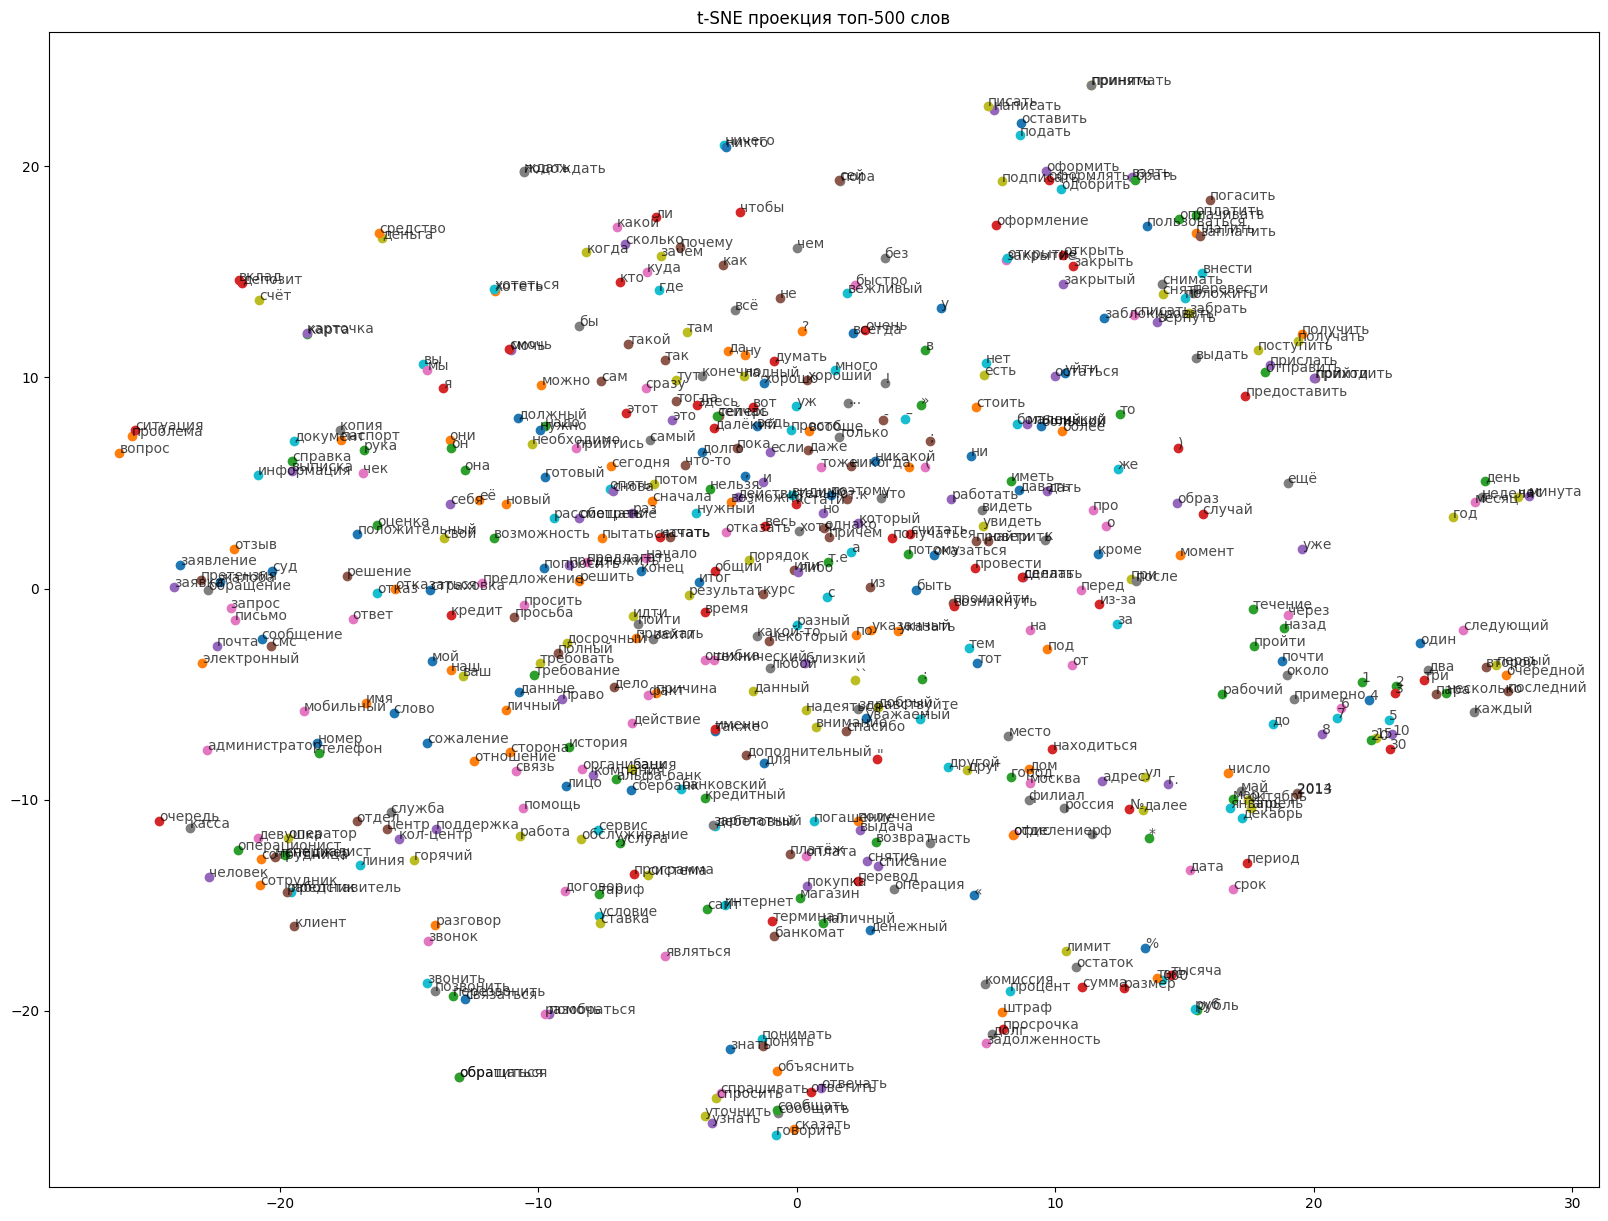

In [21]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Получаем топ-500 слов по частоте
words = sorted(model.wv.key_to_index.keys(),
              key=lambda x: model.wv.get_vecattr(x, "count"),
              reverse=True)[:500]
vectors = [model.wv[word] for word in words]

# Применяем t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=25)
projections = tsne.fit_transform(np.array(vectors))

# Визуализируем
plt.figure(figsize=(20, 15))
for i, word in enumerate(words):
    plt.scatter(projections[i, 0], projections[i, 1])
    plt.annotate(word, (projections[i, 0], projections[i, 1]),
                 alpha=0.7)
plt.title("t-SNE проекция топ-500 слов")
plt.show()

1. **Близость точек**:
   - точки находящиеся близко друг к другу на графике, и соответствующие им слова имеют схожие значения или контекстуальное употребление.

2. **Кластеры**:
   - можно заметить кластеры – группы слов, которые располагаются компактно относительно других групп. Которые объединяют слова с похожими значениями или тематикой.

3. **Распределение слов**:
   - слова распределены равномерно, это может указывать на сбалансированное представление различных тем.

В целом, такой график помогает визуально оценить структуру корпуса текстов и понять, насколько точно модель Word2Vec смогла выявить семантическое сходство между словами.

## Шаг 5: Создание семантических осей

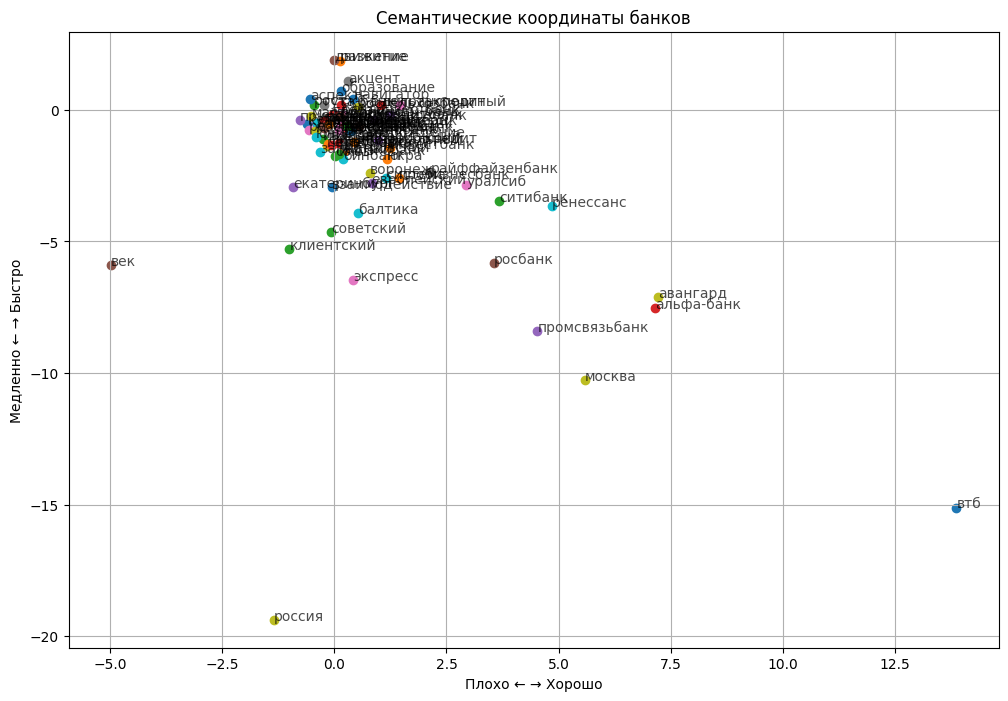

In [22]:
# Функция для расчета координат
def get_semantic_coordinates(word, axis1, axis2):
    if word not in model.wv:
        return None
    vec = model.wv[word]
    coord1 = np.dot(vec, axis1)
    coord2 = np.dot(vec, axis2)
    return (coord1, coord2)

# Определяем оси
axis_good_bad = model.wv['хороший'] - model.wv['плохой']
axis_fast_slow = model.wv['быстрый'] - model.wv['медленный']

# Получаем названия банков из данных
bank_names = list(set([resp['bank_name'].lower() for resp in responses]))

# Рассчитываем координаты
coordinates = {}
for bank in bank_names:
    if bank in model.wv:
        coords = get_semantic_coordinates(bank, axis_good_bad, axis_fast_slow)
        coordinates[bank] = coords

# Визуализируем
plt.figure(figsize=(12, 8))
for bank, (x, y) in coordinates.items():
    plt.scatter(x, y)
    plt.annotate(bank, (x, y), alpha=0.7)
plt.xlabel("Плохо ← → Хорошо")
plt.ylabel("Медленно ← → Быстро")
plt.title("Семантические координаты банков")
plt.grid(True)
plt.show()

Если большинство точек на графике сосредоточено в верхней средней части, это означает следующее:

1. **По оси "Медленно ← → Быстро"**: Поскольку точки находятся в верхней части, это говорит о том, что большинство банков воспринимаются как "быстрые". То есть клиенты считают, что эти банки предоставляют свои услуги оперативно.

2. **По оси "Плохо ← → Хорошо"**: Так как точки находятся посередине, это указывает на нейтральное восприятие большинства банков. Они не оцениваются как однозначно хорошие или плохие, скорее занимают промежуточное положение.

Таким образом, можно сделать вывод, что клиенты в основном довольны скоростью работы этих банков, но их общее впечатление о качестве обслуживания варьируется и не имеет ярко выраженного положительного или отрицательного оттенка.

# Часть 2. Распространение метки
Определите 5-8 позитивных слов (например, “быстрый”, “удобный”) и 5-8  негативных слов (например,“очередь”, “медленно”). Эти слова будут основной будущего оценочного словаря. Пусть позитивному классу соответствует метка 1, негативному – -1. Пометьте выбранные слова в лексическом графе соответствующими метками. Запустите любой известный вам метод распространения метки (Label Propogation) в лексическом графе. На выходе метода распространения ошибки должны быть новые слова, помеченные метками 1 и -1 – это и есть искомые оценочные слова.

Алгоритмы распространения метки устроены примерно так: пусть мы находимся в выршине, помеченном +1. С какой-то вероятностью мы переносим эту метку на соседние узлы. С меньшей вероятностью переносим ее на вершины на расстоянии два. В конце распространения метки, часть вершин оказывается помечена меткой +1, часть – -1, большая часть остается без метки.

Рекомендуемые алгоритмы распространения метки:
1. ```graphlab.label_propagation``` (```graphlab``` доступен бесплатно по образовательной лицензии)
2. ```sklearn.semi_supervised.LabelPropagation```
3. ```sklearn.semi_supervised.LabelSpreading```

In [143]:
# Импорт необходимых библиотек
import numpy as np
from scipy import sparse
from scipy.sparse.csgraph import connected_components
import networkx as nx
from tqdm import tqdm
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
import pymorphy3

In [144]:
# Шаг 1: Определение начальных позитивных и негативных слов-семян
positive_seeds = ['вежливый', 'оперативный', 'бонус', 'рекомендовать', 'лояльный']
negative_seeds = ['мошенничество', 'глюк', 'задержка', 'разочарование', 'претензия']

# Проверяем наличие слов в модели
valid_positive = [word for word in positive_seeds if word in model.wv]
valid_negative = [word for word in negative_seeds if word in model.wv]
print(f"Позитивные семена: {valid_positive}")
print(f"Негативные семена: {valid_negative}")

Позитивные семена: ['вежливый', 'оперативный', 'бонус', 'рекомендовать', 'лояльный']
Негативные семена: ['мошенничество', 'глюк', 'задержка', 'разочарование', 'претензия']


In [145]:
# 2. Построение графа
top_words = sorted(model.wv.key_to_index.keys(),
                 key=lambda x: model.wv.get_vecattr(x, "count"),
                 reverse=True)[:3000]  # Уменьшаем размер графа для стабильности


In [176]:
# Параметры построения графа
TOP_N = 10       # Число связей на слово
MIN_SIM = 0.4    # Минимальная косинусная близость

rows, cols, data = [], [], []
for idx, word in enumerate(tqdm(top_words)):
    try:
        # Ищем только связи с семенами и близкими словами
        sims = model.wv.most_similar(word, topn=TOP_N)
        for sim_word, score in sims:
            if sim_word in top_words and score > MIN_SIM:
                sim_idx = top_words.index(sim_word)
                rows.append(idx)
                cols.append(sim_idx)
                data.append(score)
    except KeyError:
        continue

adj_matrix = sparse.csr_matrix((data, (rows, cols)),
                              shape=(len(top_words), len(top_words)),
                              dtype=np.float32)


100%|██████████| 3000/3000 [00:14<00:00, 212.63it/s]


In [177]:
# 3. Анализ связности
n_components, _ = connected_components(adj_matrix, directed=False)
print(f"Число компонент связности: {n_components}")

Число компонент связности: 69


In [178]:
# 4. Персонализированный PageRank
G = nx.from_scipy_sparse_array(adj_matrix)

# Создаем вектор персонализации
personalization = {i: 0.0 for i in range(len(top_words))}
for seed in valid_positive:
    if seed in top_words:
        personalization[top_words.index(seed)] = 1.0
for seed in valid_negative:
    if seed in top_words:
        personalization[top_words.index(seed)] = -1.0

pr = nx.pagerank(G, alpha=0.8, personalization=personalization, max_iter=200)

In [179]:
# 5. Извлечение результатов
pr_scores = np.array([pr[i] for i in range(len(top_words))])

# Автоматический подбор порогов
pos_threshold = np.quantile(pr_scores, 0.85)
neg_threshold = np.quantile(pr_scores, 0.15)

positive_words = []
negative_words = []

for idx, score in enumerate(pr_scores):
    word = top_words[idx]
    if word in valid_positive + valid_negative:
        continue
    if score >= pos_threshold:
        positive_words.append(word)
    elif score <= neg_threshold:
        negative_words.append(word)


In [180]:
print(f"\nНовых позитивных слов: {len(positive_words)}")
print("Топ-10 позитивных:", positive_words[:10])
print(f"\nНовых негативных слов: {len(negative_words)}")
print("Топ-10 негативных:", negative_words[:10])


Новых позитивных слов: 445
Топ-10 позитивных: ['карта', 'очень', 'решить', 'обслуживание', 'стать', 'являться', 'хороший', 'предложить', 'попросить', 'отношение']

Новых негативных слов: 447
Топ-10 негативных: ['кредит', 'заявление', 'вопрос', 'платёж', 'ответ', 'договор', 'проблема', 'документ', 'звонок', 'ситуация']



### **Выводы:**
   - Алгоритм успешно распространил метки на слова, которые семантически близки к начальным семенам. Это позволяет расширить оценочный словарь, что может быть полезно для задач анализа тональности текста.
   - Однако, стоит отметить, что некоторые из выявленных слов могут быть неоднозначными. Например, слово "карта" может быть как позитивным (в контексте удобства использования), так и нейтральным. Это указывает на необходимость дополнительной проверки и ручной корректировки результатов.
   - В целом, метод показал свою эффективность для автоматического расширения оценочного словаря, но требует дополнительной постобработки для повышения точности.

### **Рекомендации:**
   - Для улучшения результатов можно попробовать использовать более точные модели word2vec или другие методы представления слов (например, fastText, BERT).
   - Также можно экспериментировать с параметрами алгоритма (например, порогами для отнесения слов к позитивным или негативным классам) и добавлять больше начальных семян для повышения качества распространения меток.
   - Для повышения точности можно использовать ручную проверку и корректировку результатов, особенно для слов, которые могут быть неоднозначными.